# F2_02 Análisis exploratorio de datos

## Finalidad

Comprender la **calidad, cobertura y patrones** de los datos obtenidos en la Fase 2 antes de realizar transformaciones.

Este notebook realiza un análisis exploratorio sobre los archivos CSV disponibles en `F2/data`, considerando:

- dimensiones y estructura de las tablas;
- tipos de datos;
- valores faltantes;
- registros duplicados;
- categorías y valores inesperados;
- distribución de votos;
- participación por votación;
- composición política cuando exista información de partido o militancia;
- detección preliminar de votaciones unánimes.



## 1. Configuración de imports y configuraciones

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [2]:
# Detectar la carpeta F2 de forma robusta.

cwd = Path.cwd().resolve()

candidatos = [cwd] + list(cwd.parents)

BASE_DIR = None

for candidato in candidatos:
    if candidato.name == "F2" and (candidato / "data").exists():
        BASE_DIR = candidato
        break

if BASE_DIR is None:
    for candidato in candidatos:
        posible = candidato / "F2"
        if (posible / "data").exists():
            BASE_DIR = posible
            break

if BASE_DIR is None:
    raise FileNotFoundError(
        "No se pudo localizar la carpeta F2/data. "
        "Ejecuta el notebook desde el repositorio del proyecto."
    )

DATA_DIR = BASE_DIR / "data"

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")

BASE_DIR: /home/sebastian/Escritorio/magister/grupo_1_programacion_ciencia_datos/F2
DATA_DIR: /home/sebastian/Escritorio/magister/grupo_1_programacion_ciencia_datos/F2/data


## 2. Inventario de archivos CSV

Se identifican automáticamente todos los CSV disponibles dentro de `F2/data`.

Esto permite que el notebook siga funcionando si posteriormente se agregan nuevas tablas en `interim` o `processed`.


In [3]:
archivos_csv = sorted(DATA_DIR.rglob("*.csv"))

print(f"CSV encontrados: {len(archivos_csv)}")

for archivo in archivos_csv:
    print("-", archivo.relative_to(BASE_DIR))


CSV encontrados: 5
- data/interim/VotacionesPorProyectoDeLey/proyecto_ley.csv
- data/interim/diputados.csv
- data/interim/militancias.csv
- data/interim/periodos.csv
- data/interim/votaciones/detalle_votaciones.csv


## 3. Carga de datasets

Cada archivo CSV se carga en un diccionario de DataFrames.

La clave utilizada combina la carpeta relativa y el nombre del archivo para evitar colisiones si existen CSV con el mismo nombre en distintas carpetas.

In [4]:
tablas = {}

for archivo in archivos_csv:
    clave = str(archivo.relative_to(DATA_DIR).with_suffix("")).replace("/", "__")
    df = pd.read_csv(archivo)
    tablas[clave] = df

    print(
        f"{clave}: "
        f"{df.shape[0]} filas x {df.shape[1]} columnas"
    )

interim__VotacionesPorProyectoDeLey__proyecto_ley: 15 filas x 15 columnas
interim__diputados: 157 filas x 13 columnas
interim__militancias: 407 filas x 6 columnas
interim__periodos: 11 filas x 4 columnas
interim__votaciones__detalle_votaciones: 1993 filas x 20 columnas


## 4. Perfil general de las tablas

Se construye una vista consolidada con:

- cantidad de filas;
- cantidad de columnas;
- total de valores faltantes;
- porcentaje global de valores faltantes;
- cantidad de filas duplicadas.

In [5]:
perfil_general = []

for nombre, df in tablas.items():
    total_celdas = df.shape[0] * df.shape[1]
    faltantes = int(df.isna().sum().sum())

    perfil_general.append({
        "tabla": nombre,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "faltantes": faltantes,
        "porcentaje_faltantes": round(
            (faltantes / total_celdas * 100) if total_celdas else 0,
            2
        ),
        "duplicados": int(df.duplicated().sum())
    })

perfil_general_df = pd.DataFrame(perfil_general)

display(perfil_general_df)

,tabla,filas,columnas,faltantes,porcentaje_faltantes,duplicados
0,interim__VotacionesPorProyectoDeLey__proyecto_ley,15,15,1,0.44,0
1,interim__diputados,157,13,628,30.77,0
2,interim__militancias,407,6,0,0.00,0
3,interim__periodos,11,4,0,0.00,0
4,interim__votaciones__detalle_votaciones,1993,20,1993,5.00,0


### Interpretación

Este perfil permite identificar rápidamente qué tablas requieren mayor atención durante el procesamiento.

Los valores faltantes y duplicados detectados aquí **no se eliminan todavía**; solo se documentan.

## 5. Tipos de datos, cardinalidad y valores faltantes por columna

Para cada tabla se revisan:

- tipo inferido por pandas;
- cantidad de valores faltantes;
- porcentaje de faltantes;
- cantidad de valores únicos.

Esto ayuda a detectar columnas que posteriormente requerirán conversión de tipo, por ejemplo fechas almacenadas como `object`.

In [6]:
def perfil_columnas(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "columna": df.columns,
        "tipo": df.dtypes.astype(str).values,
        "faltantes": df.isna().sum().values,
        "porcentaje_faltantes": (df.isna().mean().values * 100).round(2),
        "valores_unicos": df.nunique(dropna=False).values
    })


perfiles_columnas = {}

for nombre, df in tablas.items():
    print(f"\n===== {nombre} =====")
    perfil = perfil_columnas(df)
    perfiles_columnas[nombre] = perfil
    display(perfil)


===== interim__VotacionesPorProyectoDeLey__proyecto_ley =====


,columna,tipo,faltantes,porcentaje_faltantes,valores_unicos
0,numero_boletin,str,0,0.00,1
1,Id,int64,0,0.00,15
2,Descripcion,str,0,0.00,1
3,Fecha,str,0,0.00,15
4,TotalSi,int64,0,0.00,10
5,TotalNo,int64,0,0.00,10
6,TotalAbstencion,int64,0,0.00,7
7,TotalDispensado,int64,0,0.00,1
8,Quorum,str,0,0.00,2
9,Resultado,str,0,0.00,1



===== interim__diputados =====


,columna,tipo,faltantes,porcentaje_faltantes,valores_unicos
0,diputado_id,int64,0,0.0,157
1,nombre,str,0,0.0,119
2,nombre2,float64,157,100.0,1
3,apellido_paterno,str,0,0.0,143
4,apellido_materno,str,0,0.0,132
5,fecha_nacimiento,str,0,0.0,157
6,rut,float64,157,100.0,1
7,rut_dv,float64,157,100.0,1
8,sexo_valor,int64,0,0.0,2
9,sexo_desc,str,0,0.0,2



===== interim__militancias =====


,columna,tipo,faltantes,porcentaje_faltantes,valores_unicos
0,diputado_id,int64,0,0.0,157
1,partido_id,str,0,0.0,30
2,partido_nombre,str,0,0.0,29
3,partido_alias,str,0,0.0,30
4,fecha_inicio,str,0,0.0,70
5,fecha_termino,str,0,0.0,66



===== interim__periodos =====


,columna,tipo,faltantes,porcentaje_faltantes,valores_unicos
0,periodo_id,int64,0,0.0,11
1,nombre,str,0,0.0,11
2,fecha_inicio,str,0,0.0,11
3,fecha_termino,str,0,0.0,11



===== interim__votaciones__detalle_votaciones =====


,columna,tipo,faltantes,porcentaje_faltantes,valores_unicos
0,diputado_id,int64,0,0.0,151
1,nombre,str,0,0.0,117
2,nombre2,float64,1993,100.0,1
3,apellido_paterno,str,0,0.0,138
4,apellido_materno,str,0,0.0,129
5,opcion_codigo,int64,0,0.0,3
6,opcion_voto,str,0,0.0,3
7,votacion_id,int64,0,0.0,15
8,descripcion,str,0,0.0,1
9,fecha,str,0,0.0,15


## 6. Registros duplicados

Se revisan duplicados exactos por tabla.

Una fila duplicada no necesariamente implica un error: su interpretación depende de la entidad representada y de la clave lógica de cada tabla.


In [7]:
resumen_duplicados = []

for nombre, df in tablas.items():
    duplicados = int(df.duplicated().sum())

    resumen_duplicados.append({
        "tabla": nombre,
        "duplicados": duplicados
    })

resumen_duplicados_df = pd.DataFrame(resumen_duplicados)

display(resumen_duplicados_df)


,tabla,duplicados
0,interim__VotacionesPorProyectoDeLey__proyecto_ley,0
1,interim__diputados,0
2,interim__militancias,0
3,interim__periodos,0
4,interim__votaciones__detalle_votaciones,0


In [8]:
# Mostrar ejemplos de duplicados cuando existan

for nombre, df in tablas.items():
    duplicados = df[df.duplicated(keep=False)]

    if not duplicados.empty:
        print(f"\nDuplicados detectados en: {nombre}")
        display(duplicados.head(20))

## 7. Variables categóricas y valores inesperados

Se inspeccionan automáticamente las columnas con baja cardinalidad.

Esto permite detectar categorías inconsistentes, por ejemplo:

- diferencias de mayúsculas/minúsculas;
- variantes ortográficas;
- categorías no esperadas;
- valores nulos representados como texto.

In [9]:
def columnas_categoricas(df: pd.DataFrame, max_categorias: int = 30) -> list[str]:
    columnas = []

    for columna in df.columns:
        n_unicos = df[columna].nunique(dropna=False)

        if n_unicos <= max_categorias:
            columnas.append(columna)

    return columnas


for nombre, df in tablas.items():
    print(f"\n===== {nombre} =====")

    categorias = columnas_categoricas(df)

    for columna in categorias:
        print(f"\nColumna: {columna}")
        display(
            df[columna]
            .value_counts(dropna=False)
            .rename("cantidad")
            .to_frame()
        )



===== interim__VotacionesPorProyectoDeLey__proyecto_ley =====

Columna: numero_boletin


,cantidad
numero_boletin,
11092-07,15



Columna: Id


,cantidad
Id,
42724,1
21219,1
21218,1
21217,1
20637,1
20636,1
20635,1
20634,1
20633,1



Columna: Descripcion


...

,cantidad
resultado,
Aprobado,1993



Columna: tipo_codigo


,cantidad
tipo_codigo,
1,1993



Columna: tipo


,cantidad
tipo,
Proyecto de Ley,1993


## 8. Identificación del dataset de votos nominales

El análisis específico de votos, participación y unanimidad requiere una tabla que contenga al menos:

- identificador de votación;
- opción de voto.

El notebook intenta localizar automáticamente una tabla compatible.

In [10]:
def encontrar_tabla_votos(tablas: dict[str, pd.DataFrame]):
    candidatos_id = {"votacion_id", "id_votacion", "Id"}
    candidatos_voto = {"opcion_voto", "voto", "OpcionVoto"}

    for nombre, df in tablas.items():
        columnas = set(df.columns)

        id_col = next((c for c in candidatos_id if c in columnas), None)
        voto_col = next((c for c in candidatos_voto if c in columnas), None)

        if id_col and voto_col:
            return nombre, df, id_col, voto_col

    return None, None, None, None


nombre_votos, df_votos, col_id_votacion, col_opcion_voto = encontrar_tabla_votos(tablas)

if df_votos is None:
    print("No se encontró una tabla compatible con votos nominales.")
else:
    print(f"Tabla de votos detectada: {nombre_votos}")
    print(f"ID votación: {col_id_votacion}")
    print(f"Opción de voto: {col_opcion_voto}")
    display(df_votos.head())


Tabla de votos detectada: interim__votaciones__detalle_votaciones
ID votación: votacion_id
Opción de voto: opcion_voto


,diputado_id,nombre,nombre2,apellido_paterno,apellido_materno,opcion_codigo,opcion_voto,votacion_id,descripcion,fecha,total_si,total_no,total_abstencion,total_dispensado,quorum_codigo,quorum,resultado_codigo,resultado,tipo_codigo,tipo
0,803,René,NaN,Alinco,Bustos,0,En Contra,42724,Boletín N° 11092-07,2024-08-26T19:03:25,65,22,36,0,2,Quórum Calificado,1,Aprobado,1,Proyecto de Ley
1,815,Sergio,NaN,Bobadilla,Muñoz,2,Abstención,42724,Boletín N° 11092-07,2024-08-26T19:03:25,65,22,36,0,2,Quórum Calificado,1,Aprobado,1,Proyecto de Ley
2,872,Jaime,NaN,Mulet,Martínez,1,Afirmativo,42724,Boletín N° 11092-07,2024-08-26T19:03:25,65,22,36,0,2,Quórum Calificado,1,Aprobado,1,Proyecto de Ley
3,917,Gastón,NaN,Von Mühlenbrock,Zamora,0,En Contra,42724,Boletín N° 11092-07,2024-08-26T19:03:25,65,22,36,0,2,Quórum Calificado,1,Aprobado,1,Proyecto de Ley
4,948,Gaspar,NaN,Rivas,Sánchez,2,Abstención,42724,Boletín N° 11092-07,2024-08-26T19:03:25,65,22,36,0,2,Quórum Calificado,1,Aprobado,1,Proyecto de Ley


## 9. Distribución de opciones de voto

Se analiza cuántos registros existen para cada opción de voto.

La visualización permite detectar rápidamente predominio de votos afirmativos, negativos, abstenciones u otras categorías disponibles en la fuente.

**Fuente:** Cámara de Diputadas y Diputados de Chile, API Open Data; datos extraídos por el pipeline de la Fase 2.

,cantidad
opcion_voto,
Afirmativo,1379
En Contra,546
Abstención,68


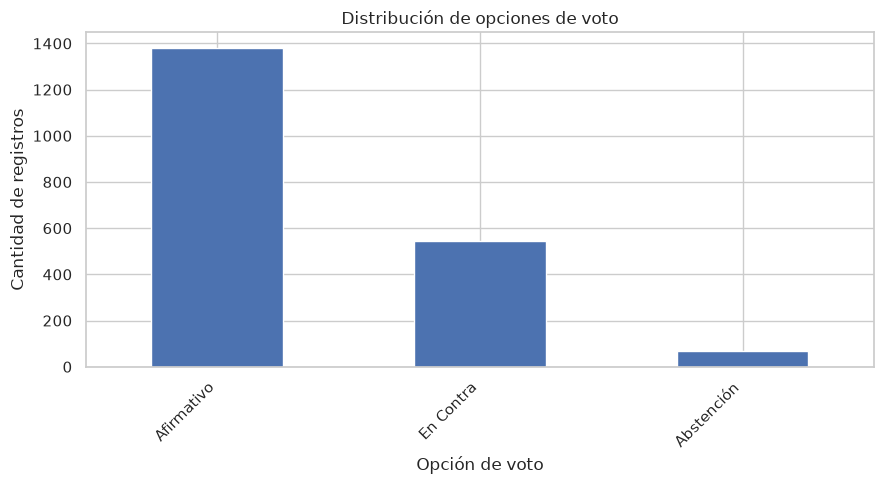

In [11]:
if df_votos is not None:
    distribucion_votos = (
        df_votos[col_opcion_voto]
        .value_counts(dropna=False)
        .rename("cantidad")
    )

    display(distribucion_votos.to_frame())

    ax = distribucion_votos.plot(kind="bar", figsize=(9, 5))
    ax.set_title("Distribución de opciones de voto")
    ax.set_xlabel("Opción de voto")
    ax.set_ylabel("Cantidad de registros")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 10. Participación por votación

Se calcula el número de registros nominales asociados a cada votación.

En esta etapa se utiliza la cantidad de votos registrados como aproximación de participación. La interpretación definitiva de ausencias, dispensas y abstenciones se realizará en la etapa de procesamiento y validación.

**Fuente:** Cámara de Diputadas y Diputados de Chile, API Open Data; datos extraídos por el pipeline de la Fase 2.

,votacion_id,registros_voto
0,20627,122
1,20628,128
2,20629,135
3,20630,135
4,20631,135


,registros_voto
count,15.000000
mean,132.866667
std,4.580497
min,122.000000
25%,135.000000
50%,135.000000
75%,135.000000
max,135.000000


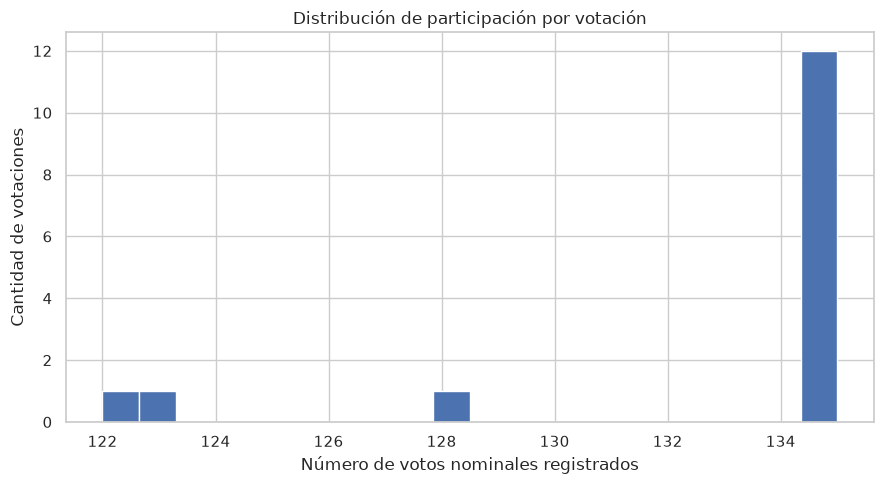

In [12]:
if df_votos is not None:
    participacion = (
        df_votos
        .groupby(col_id_votacion)
        .size()
        .reset_index(name="registros_voto")
    )

    display(participacion.head())
    display(participacion["registros_voto"].describe().to_frame())

    ax = participacion["registros_voto"].plot(
        kind="hist",
        bins=20,
        figsize=(9, 5)
    )
    ax.set_title("Distribución de participación por votación")
    ax.set_xlabel("Número de votos nominales registrados")
    ax.set_ylabel("Cantidad de votaciones")
    plt.tight_layout()
    plt.show()

## 11. Detección preliminar de votaciones unánimes

Una votación se considera **potencialmente unánime** cuando todos los registros poseen una sola categoría de voto.

Esta es una detección exploratoria. En la fase siguiente deberá definirse formalmente cómo tratar abstenciones, ausencias y dispensas al calcular unanimidad.


In [13]:
if df_votos is not None:
    opciones_por_votacion = (
        df_votos
        .groupby(col_id_votacion)[col_opcion_voto]
        .nunique(dropna=True)
        .rename("cantidad_opciones")
    )

    votaciones_unanimes = opciones_por_votacion[
        opciones_por_votacion == 1
    ]

    total_votaciones = len(opciones_por_votacion)
    total_unanimes = len(votaciones_unanimes)

    porcentaje_unanimes = (
        total_unanimes / total_votaciones * 100
        if total_votaciones
        else 0
    )

    print(f"Votaciones analizadas: {total_votaciones}")
    print(f"Potencialmente unánimes: {total_unanimes}")
    print(f"Porcentaje: {porcentaje_unanimes:.2f}%")

    display(
        votaciones_unanimes
        .reset_index()
        .head(20)
    )


Votaciones analizadas: 15
Potencialmente unánimes: 2
Porcentaje: 13.33%


,votacion_id,cantidad_opciones
0,20627,1
1,20628,1


## 12. Composición política

Se busca una tabla que contenga información de partido o militancia.

Si existe, se muestra la distribución de registros por agrupación política. La interpretación debe considerar la vigencia temporal de la militancia, que será tratada formalmente en la etapa de procesamiento.


Tabla detectada: interim__militancias
Columna utilizada: partido_nombre


,cantidad
partido_nombre,
Independientes,89
Renovación Nacional,50
Unión Demócrata Independiente,47
Partido Socialista,34
Frente Amplio,31
Partido Republicano,24
Partido Comunista,22
Partido Demócrata Cristiano,13
Revolución Democrática,11


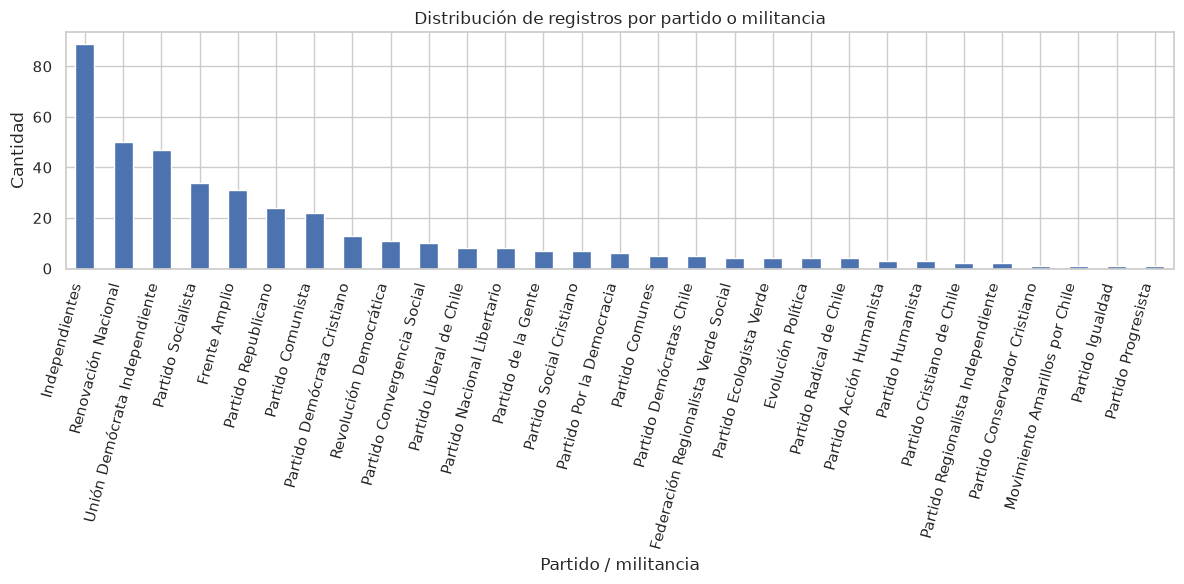

In [14]:
def encontrar_columna_partido(tablas: dict[str, pd.DataFrame]):
    candidatos = [
        "partido",
        "Partido",
        "militancia",
        "Militancia",
        "nombre_partido",
        "partido_nombre"
    ]

    for nombre, df in tablas.items():
        for columna in candidatos:
            if columna in df.columns:
                return nombre, df, columna

    return None, None, None


nombre_partidos, df_partidos, col_partido = encontrar_columna_partido(tablas)

if df_partidos is None:
    print("No se encontró una columna de partido o militancia en los CSV disponibles.")
else:
    print(f"Tabla detectada: {nombre_partidos}")
    print(f"Columna utilizada: {col_partido}")

    distribucion_partidos = (
        df_partidos[col_partido]
        .value_counts(dropna=False)
        .rename("cantidad")
    )

    display(distribucion_partidos.to_frame())

    ax = distribucion_partidos.head(30).plot(
        kind="bar",
        figsize=(12, 6)
    )
    ax.set_title("Distribución de registros por partido o militancia")
    ax.set_xlabel("Partido / militancia")
    ax.set_ylabel("Cantidad")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

## 13. Resumen automático de hallazgos

Se genera un resumen cuantitativo para apoyar la documentación final del análisis.

In [15]:
# Resumen automático de hallazgos de la exploración original

total_filas = sum(len(df) for df in tablas.values())
total_faltantes = sum(int(df.isna().sum().sum()) for df in tablas.values())
total_duplicados = sum(int(df.duplicated().sum()) for df in tablas.values())

print("RESUMEN DE EXPLORACIÓN")
print("-" * 60)
print(f"CSV analizados: {len(tablas)}")
print(f"Filas totales: {total_filas}")
print(f"Valores faltantes: {total_faltantes}")
print(f"Duplicados exactos: {total_duplicados}")

if df_votos is not None:
    print(f"Votaciones con votos nominales: {df_votos[col_id_votacion].nunique()}")
    print(f"Registros nominales: {len(df_votos)}")

RESUMEN DE EXPLORACIÓN
------------------------------------------------------------
CSV analizados: 5
Filas totales: 2583
Valores faltantes: 2622
Duplicados exactos: 0
Votaciones con votos nominales: 15
Registros nominales: 1993


## 13.1 Contrato de datos y reproducibilidad

Se complementa el EDA original con controles de integridad y reproducibilidad, sin repetir los análisis descriptivos anteriores.

| Tabla | Unidad de observación | Clave lógica esperada |
|---|---|---|
| `proyecto_ley` | una votación | `Id` |
| `diputados` | un diputado | `diputado_id` |
| `periodos` | un período legislativo | `periodo_id` |
| `detalle_votaciones` | un voto nominal | `votacion_id + diputado_id` |
| `militancias` | una afiliación durante un intervalo | `diputado_id + partido_id + fecha_inicio` |

Los identificadores se consideran obligatorios. Columnas completamente vacías se tratan como **estructuralmente vacías** hasta definir su uso en F2_03.

In [16]:
import platform
import sys
from datetime import datetime, timezone



reproducibilidad = pd.DataFrame([
    {
        "archivo": str(archivo.relative_to(BASE_DIR)),
        "bytes": archivo.stat().st_size,
        "modificado_utc": datetime.fromtimestamp(
            archivo.stat().st_mtime,
            tz=timezone.utc
        ).isoformat()
    }
    for archivo in archivos_csv
])


print("Fecha de ejecución UTC:", datetime.now(timezone.utc).isoformat())

display(reproducibilidad)

Fecha de ejecución UTC: 2026-09-13T22:32:34.907956+00:00


,archivo,bytes,modificado_utc
0,data/interim/VotacionesPorProyectoDeLey/proyec...,5144,2026-09-12T21:44:27.381159+00:00
1,data/interim/diputados.csv,14093,2026-09-13T20:46:31.378496+00:00
2,data/interim/militancias.csv,30477,2026-09-13T17:57:35.679138+00:00
3,data/interim/periodos.csv,520,2026-09-13T17:57:35.679179+00:00
4,data/interim/votaciones/detalle_votaciones.csv,294225,2026-09-13T17:57:35.679383+00:00


## 13.2 Controles semánticos adicionales

Se agregan controles puntuales que no estaban en el EDA original:

- fechas no parseables;
- espacios laterales en textos;
- números negativos;
- identificadores nulos o no positivos.

Estos controles solo reportan problemas; no modifican los datos.

In [17]:
controles_semanticos = []

for nombre, df in tablas.items():
    # Fechas no parseables
    for columna in [c for c in df.columns if "fecha" in c.lower()]:
        original = df[columna]
        parseada = pd.to_datetime(original, errors="coerce")
        controles_semanticos.append({
            "tabla": nombre,
            "columna": columna,
            "control": "fecha_no_parseable",
            "cantidad": int((original.notna() & parseada.isna()).sum())
        })

    # Espacios laterales
    for columna in df.select_dtypes(include=["object", "string"]).columns:
        serie = df[columna].dropna().astype(str)
        controles_semanticos.append({
            "tabla": nombre,
            "columna": columna,
            "control": "espacios_laterales",
            "cantidad": int((serie != serie.str.strip()).sum())
        })

    # Números negativos
    for columna in df.select_dtypes(include=["number"]).columns:
        serie = pd.to_numeric(df[columna], errors="coerce")
        controles_semanticos.append({
            "tabla": nombre,
            "columna": columna,
            "control": "valores_negativos",
            "cantidad": int((serie < 0).sum())
        })

controles_semanticos_df = pd.DataFrame(controles_semanticos)
display(
    controles_semanticos_df[
        controles_semanticos_df["cantidad"] > 0
    ]
)

,tabla,columna,control,cantidad
8,interim__VotacionesPorProyectoDeLey__proyecto_ley,Articulo,espacios_laterales,10


## 13.3 Identificación de tablas para controles de integridad

In [18]:
def encontrar_tabla_por_columnas(tablas, columnas_requeridas):
    requeridas = set(columnas_requeridas)

    for nombre, df in tablas.items():
        if requeridas.issubset(df.columns):
            return nombre, df

    return None, None


nombre_proyecto, df_proyecto = encontrar_tabla_por_columnas(
    tablas, ["Id", "Fecha"]
)

nombre_diputados, df_diputados = encontrar_tabla_por_columnas(
    tablas, ["diputado_id", "periodo_id"]
)

nombre_periodos, df_periodos = encontrar_tabla_por_columnas(
    tablas, ["periodo_id", "fecha_inicio", "fecha_termino"]
)

nombre_militancias, df_militancias = encontrar_tabla_por_columnas(
    tablas, ["diputado_id", "partido_id", "fecha_inicio", "fecha_termino"]
)

nombre_detalle, df_detalle = encontrar_tabla_por_columnas(
    tablas, ["votacion_id", "diputado_id", "opcion_voto"]
)

print("proyecto_ley:", nombre_proyecto)
print("diputados:", nombre_diputados)
print("periodos:", nombre_periodos)
print("militancias:", nombre_militancias)
print("detalle_votaciones:", nombre_detalle)

proyecto_ley: interim__VotacionesPorProyectoDeLey__proyecto_ley
diputados: interim__diputados
periodos: interim__periodos
militancias: interim__militancias
detalle_votaciones: interim__votaciones__detalle_votaciones


## 13.4 Estadísticas descriptivas de los diputados

Se agregan estadísticas demográficas para complementar el EDA:

- distribución y porcentaje por sexo;
- edad promedio;
- mediana, desviación estándar, mínimo, máximo y cuartiles de edad;
- distribución de edades;
- comparación de edad por sexo.

La edad se calcula usando como **fecha de referencia la votación más reciente del conjunto**, de modo que la estadística sea coherente con el período analizado y no dependa de la fecha en que se ejecute el notebook.

Estadísticas de edad:


,estadistica,valor
0,Fecha de referencia,2024-08-26 19:03:25
1,Diputados con edad calculable,157
2,Edad promedio,49.63
3,Mediana,49.0
4,Desviación estándar,12.17
5,Mínimo,27
6,Q1 (25%),39.0
7,Q3 (75%),58.0
8,Máximo,81


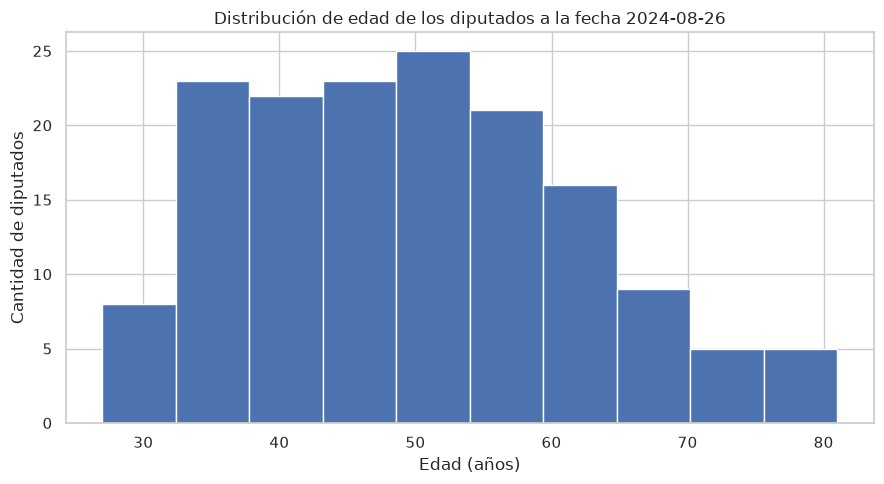

In [19]:
#estadistica descriptiva
import ast
import numpy as np

def extraer_sexo(valor):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip()

    # La API puede haber dejado una estructura serializada.
    if texto.startswith("{") and texto.endswith("}"):
        try:
            obj = ast.literal_eval(texto)

            if isinstance(obj, dict):
                for clave in ["_value_1", "value", "sexo"]:
                    if clave in obj:
                        return str(obj[clave]).strip()
        except (ValueError, SyntaxError):
            pass

    return texto


estadisticas_demograficas = {}

if df_diputados is not None:
    diputados_demo = df_diputados.copy()

    # Sexo normalizado solo en memoria para fines exploratorios.
    if "sexo" in diputados_demo.columns:
        diputados_demo["sexo_eda"] = (
            diputados_demo["sexo"]
            .apply(extraer_sexo)
        )

        sexo_resumen = (
            diputados_demo["sexo_eda"]
            .value_counts(dropna=False)
            .rename("cantidad")
            .to_frame()
        )

        sexo_resumen["porcentaje"] = (
            sexo_resumen["cantidad"]
            / len(diputados_demo)
            * 100
        ).round(2)

        print("Distribución por sexo:")
        display(sexo_resumen)

        ax = sexo_resumen["porcentaje"].plot(
            kind="bar",
            figsize=(8, 5)
        )
        ax.set_title("Distribución porcentual de diputados por sexo")
        ax.set_xlabel("Sexo")
        ax.set_ylabel("Porcentaje (%)")
        plt.xticks(rotation=0)

        for contenedor in ax.containers:
            ax.bar_label(
                contenedor,
                fmt="%.1f%%"
            )

        plt.tight_layout()
        plt.show()

    # Fecha de referencia = votación más reciente.
    fecha_referencia = None

    if df_detalle is not None and "fecha" in df_detalle.columns:
        fechas_voto = pd.to_datetime(
            df_detalle["fecha"],
            errors="coerce"
        )
        fecha_referencia = fechas_voto.max()

    elif df_proyecto is not None and "Fecha" in df_proyecto.columns:
        fechas_voto = pd.to_datetime(
            df_proyecto["Fecha"],
            errors="coerce"
        )
        fecha_referencia = fechas_voto.max()

    if (
        fecha_referencia is not None
        and pd.notna(fecha_referencia)
        and "fecha_nacimiento" in diputados_demo.columns
    ):
        diputados_demo["fecha_nacimiento_dt"] = pd.to_datetime(
            diputados_demo["fecha_nacimiento"],
            errors="coerce"
        )

        nacimiento = diputados_demo["fecha_nacimiento_dt"]

        diputados_demo["edad_referencia"] = (
            fecha_referencia.year
            - nacimiento.dt.year
            - (
                (
                    (fecha_referencia.month < nacimiento.dt.month)
                    |
                    (
                        (fecha_referencia.month == nacimiento.dt.month)
                        &
                        (fecha_referencia.day < nacimiento.dt.day)
                    )
                )
            ).astype("Int64")
        )

        edades = pd.to_numeric(
            diputados_demo["edad_referencia"],
            errors="coerce"
        )

        resumen_edad = pd.DataFrame({
            "estadistica": [
                "Fecha de referencia",
                "Diputados con edad calculable",
                "Edad promedio",
                "Mediana",
                "Desviación estándar",
                "Mínimo",
                "Q1 (25%)",
                "Q3 (75%)",
                "Máximo"
            ],
            "valor": [
                str(fecha_referencia),
                int(edades.notna().sum()),
                round(edades.mean(), 2),
                round(edades.median(), 2),
                round(edades.std(), 2),
                edades.min(),
                round(edades.quantile(0.25), 2),
                round(edades.quantile(0.75), 2),
                edades.max()
            ]
        })

        print("Estadísticas de edad:")
        display(resumen_edad)

        ax = edades.dropna().plot(
            kind="hist",
            bins=10,
            figsize=(9, 5)
        )
        ax.set_title(
            "Distribución de edad de los diputados "
            f"a la fecha {fecha_referencia.date()}"
        )
        ax.set_xlabel("Edad (años)")
        ax.set_ylabel("Cantidad de diputados")
        plt.tight_layout()
        plt.show()

        if "sexo_eda" in diputados_demo.columns:
            edades_por_sexo = (
                diputados_demo
                .dropna(subset=["sexo_eda", "edad_referencia"])
                .groupby("sexo_eda")["edad_referencia"]
                .agg(
                    cantidad="count",
                    edad_promedio="mean",
                    mediana="median",
                    minimo="min",
                    maximo="max"
                )
                .round(2)
            )

            print("Edad por sexo:")
            display(edades_por_sexo)

            datos_box = [
                grupo["edad_referencia"].dropna().astype(float).values
                for _, grupo in diputados_demo
                .dropna(subset=["sexo_eda", "edad_referencia"])
                .groupby("sexo_eda")
            ]

            etiquetas_box = [
                str(nombre)
                for nombre, _ in diputados_demo
                .dropna(subset=["sexo_eda", "edad_referencia"])
                .groupby("sexo_eda")
            ]

            if datos_box:
                fig, ax = plt.subplots(figsize=(8, 5))
                ax.boxplot(
                    datos_box,
                    labels=etiquetas_box
                )
                ax.set_title("Distribución de edad por sexo")
                ax.set_xlabel("Sexo")
                ax.set_ylabel("Edad (años)")
                plt.tight_layout()
                plt.show()
    else:
        print(
            "No fue posible calcular edad: "
            "falta fecha de referencia o fecha_nacimiento."
        )

**Fuente:** Cámara de Diputadas y Diputados de Chile, API Open Data; datos extraídos por el pipeline de la Fase 2.

> La variable `sexo` se normaliza únicamente en memoria para este análisis exploratorio. La transformación definitiva corresponde a F2_03.

## 13.5 Duplicados lógicos

Además de duplicados exactos se validan claves de negocio. El control más importante es garantizar una sola fila por `votacion_id + diputado_id`.

In [20]:
controles_clave = []

def validar_clave_logica(nombre, df, columnas):
    if df is None or not set(columnas).issubset(df.columns):
        controles_clave.append({
            "tabla": nombre,
            "clave": " + ".join(columnas),
            "duplicados": None,
            "estado": "ADVERTENCIA"
        })
        return pd.DataFrame()

    mascara = df.duplicated(
        subset=columnas,
        keep=False
    )

    n = int(mascara.sum())

    controles_clave.append({
        "tabla": nombre,
        "clave": " + ".join(columnas),
        "duplicados": n,
        "estado": "OK" if n == 0 else "ERROR"
    })

    return df.loc[mascara].copy()


dup_detalle = validar_clave_logica(
    "detalle_votaciones",
    df_detalle,
    ["votacion_id", "diputado_id"]
)

validar_clave_logica(
    "proyecto_ley",
    df_proyecto,
    ["Id"]
)

validar_clave_logica(
    "diputados",
    df_diputados,
    ["diputado_id"]
)

validar_clave_logica(
    "periodos",
    df_periodos,
    ["periodo_id"]
)

validar_clave_logica(
    "militancias",
    df_militancias,
    ["diputado_id", "partido_id", "fecha_inicio"]
)

display(pd.DataFrame(controles_clave))

if not dup_detalle.empty:
    print("Votos duplicados lógicos:")
    display(dup_detalle.head(30))

,tabla,clave,duplicados,estado
0,detalle_votaciones,votacion_id + diputado_id,0,OK
1,proyecto_ley,Id,0,OK
2,diputados,diputado_id,0,OK
3,periodos,periodo_id,0,OK
4,militancias,diputado_id + partido_id + fecha_inicio,0,OK


## 13.6 Integridad referencial entre tablas

In [21]:
controles_referenciales = []

def anti_join(
    izquierda,
    derecha,
    clave_izquierda,
    clave_derecha,
    nombre_control
):
    if (
        izquierda is None
        or derecha is None
        or clave_izquierda not in izquierda.columns
        or clave_derecha not in derecha.columns
    ):
        controles_referenciales.append({
            "validacion": nombre_control,
            "fuera_catalogo": None,
            "estado": "ADVERTENCIA"
        })
        return

    catalogo = derecha[
        [clave_derecha]
    ].drop_duplicates()

    comparacion = izquierda.merge(
        catalogo,
        how="left",
        left_on=clave_izquierda,
        right_on=clave_derecha,
        indicator=True
    )

    fuera = comparacion[
        comparacion["_merge"] == "left_only"
    ]

    controles_referenciales.append({
        "validacion": nombre_control,
        "fuera_catalogo": len(fuera),
        "estado": "OK" if len(fuera) == 0 else "ERROR"
    })


anti_join(
    df_detalle, df_proyecto,
    "votacion_id", "Id",
    "Detalles con votación inexistente"
)

anti_join(
    df_proyecto, df_detalle,
    "Id", "votacion_id",
    "Votaciones de catálogo sin detalle"
)

anti_join(
    df_detalle, df_diputados,
    "diputado_id", "diputado_id",
    "Votos con diputado inexistente"
)

anti_join(
    df_militancias, df_diputados,
    "diputado_id", "diputado_id",
    "Militancias con diputado inexistente"
)

anti_join(
    df_diputados, df_periodos,
    "periodo_id", "periodo_id",
    "Diputados con período inexistente"
)

controles_referenciales_df = pd.DataFrame(
    controles_referenciales
)

display(controles_referenciales_df)


if df_proyecto is not None and df_detalle is not None:
    ids_catalogo = set(
        pd.to_numeric(
            df_proyecto["Id"],
            errors="coerce"
        ).dropna().astype(int)
    )

    ids_detalle = set(
        pd.to_numeric(
            df_detalle["votacion_id"],
            errors="coerce"
        ).dropna().astype(int)
    )

    print("Solo en catálogo:", sorted(ids_catalogo - ids_detalle))
    print("Solo en detalle:", sorted(ids_detalle - ids_catalogo))
    print("Coincidencia exacta:", ids_catalogo == ids_detalle)

,validacion,fuera_catalogo,estado
0,Detalles con votación inexistente,0,OK
1,Votaciones de catálogo sin detalle,0,OK
2,Votos con diputado inexistente,0,OK
3,Militancias con diputado inexistente,0,OK
4,Diputados con período inexistente,0,OK


Solo en catálogo: []
Solo en detalle: []
Coincidencia exacta: True


## 13.7 Conciliación de votos nominales y metadatos oficiales

In [22]:
campos_metadata = [
    "descripcion",
    "fecha",
    "total_si",
    "total_no",
    "total_abstencion",
    "total_dispensado",
    "quorum_codigo",
    "quorum",
    "resultado_codigo",
    "resultado",
    "tipo_codigo",
    "tipo"
]

consistencia_metadata = []

if df_detalle is not None:
    for campo in campos_metadata:
        if campo not in df_detalle.columns:
            continue

        inconsistencias = (
            df_detalle
            .groupby("votacion_id")[campo]
            .nunique(dropna=False)
            .gt(1)
            .sum()
        )

        consistencia_metadata.append({
            "campo": campo,
            "votaciones_inconsistentes": int(inconsistencias),
            "estado": "OK" if inconsistencias == 0 else "ERROR"
        })

consistencia_metadata_df = pd.DataFrame(
    consistencia_metadata
)

display(consistencia_metadata_df)

,campo,votaciones_inconsistentes,estado
0,descripcion,0,OK
1,fecha,0,OK
2,total_si,0,OK
3,total_no,0,OK
4,total_abstencion,0,OK
5,total_dispensado,0,OK
6,quorum_codigo,0,OK
7,quorum,0,OK
8,resultado_codigo,0,OK
9,resultado,0,OK


In [23]:
conciliacion_votos = pd.DataFrame()

requeridas = {
    "votacion_id",
    "opcion_voto",
    "total_si",
    "total_no",
    "total_abstencion",
    "total_dispensado"
}

if (
    df_detalle is not None
    and requeridas.issubset(df_detalle.columns)
):
    nominales = (
        df_detalle
        .groupby(["votacion_id", "opcion_voto"])
        .size()
        .unstack(fill_value=0)
    )

    oficiales = (
        df_detalle
        .groupby("votacion_id")
        [
            [
                "total_si",
                "total_no",
                "total_abstencion",
                "total_dispensado"
            ]
        ]
        .first()
    )

    conciliacion_votos = oficiales.copy()

    conciliacion_votos["nominal_afirmativo"] = nominales.get(
        "Afirmativo",
        pd.Series(0, index=nominales.index)
    )

    conciliacion_votos["nominal_en_contra"] = nominales.get(
        "En Contra",
        pd.Series(0, index=nominales.index)
    )

    conciliacion_votos["nominal_abstencion"] = nominales.get(
        "Abstención",
        pd.Series(0, index=nominales.index)
    )

    conciliacion_votos["n_nominal"] = (
        df_detalle
        .groupby("votacion_id")
        .size()
    )

    conciliacion_votos["total_oficial"] = (
        conciliacion_votos["total_si"]
        + conciliacion_votos["total_no"]
        + conciliacion_votos["total_abstencion"]
        + conciliacion_votos["total_dispensado"]
    )

    conciliacion_votos["ok_si"] = (
        conciliacion_votos["nominal_afirmativo"]
        == conciliacion_votos["total_si"]
    )

    conciliacion_votos["ok_no"] = (
        conciliacion_votos["nominal_en_contra"]
        == conciliacion_votos["total_no"]
    )

    conciliacion_votos["ok_abstencion"] = (
        conciliacion_votos["nominal_abstencion"]
        == conciliacion_votos["total_abstencion"]
    )

    conciliacion_votos["ok_total"] = (
        conciliacion_votos["n_nominal"]
        == conciliacion_votos["total_oficial"]
    )

    conciliacion_votos["estado"] = (
        conciliacion_votos[
            ["ok_si", "ok_no", "ok_abstencion", "ok_total"]
        ]
        .all(axis=1)
        .map({True: "OK", False: "ERROR"})
    )

    display(conciliacion_votos.reset_index())

,votacion_id,total_si,total_no,total_abstencion,total_dispensado,nominal_afirmativo,nominal_en_contra,nominal_abstencion,n_nominal,total_oficial,ok_si,ok_no,ok_abstencion,ok_total,estado
0,20627,122,0,0,0,122,0,0,122,122,True,True,True,True,OK
1,20628,128,0,0,0,128,0,0,128,128,True,True,True,True,OK
2,20629,90,42,3,0,90,42,3,135,135,True,True,True,True,OK
3,20630,90,40,5,0,90,40,5,135,135,True,True,True,True,OK
4,20631,91,43,1,0,91,43,1,135,135,True,True,True,True,OK
5,20632,93,42,0,0,93,42,0,135,135,True,True,True,True,OK
6,20633,94,39,2,0,94,39,2,135,135,True,True,True,True,OK
7,20634,94,40,1,0,94,40,1,135,135,True,True,True,True,OK
8,20635,92,40,3,0,92,40,3,135,135,True,True,True,True,OK
9,20636,92,40,3,0,92,40,3,135,135,True,True,True,True,OK


## 13.8 Correspondencia entre códigos y etiquetas

In [24]:
def revisar_correspondencia(
    df,
    codigo,
    etiqueta,
    nombre
):
    if (
        df is None
        or codigo not in df.columns
        or etiqueta not in df.columns
    ):
        return {
            "relacion": nombre,
            "codigos_multi_etiqueta": None,
            "etiquetas_multi_codigo": None,
            "estado": "ADVERTENCIA"
        }

    codigos = (
        df.groupby(codigo)[etiqueta]
        .nunique(dropna=False)
    )

    etiquetas = (
        df.groupby(etiqueta)[codigo]
        .nunique(dropna=False)
    )

    n_codigos = int((codigos > 1).sum())
    n_etiquetas = int((etiquetas > 1).sum())

    return {
        "relacion": nombre,
        "codigos_multi_etiqueta": n_codigos,
        "etiquetas_multi_codigo": n_etiquetas,
        "estado": (
            "OK"
            if n_codigos == 0 and n_etiquetas == 0
            else "ADVERTENCIA"
        )
    }


controles_catalogo_df = pd.DataFrame([
    revisar_correspondencia(
        df_detalle,
        "opcion_codigo",
        "opcion_voto",
        "opcion_codigo ↔ opcion_voto"
    ),
    revisar_correspondencia(
        df_detalle,
        "quorum_codigo",
        "quorum",
        "quorum_codigo ↔ quorum"
    ),
    revisar_correspondencia(
        df_detalle,
        "resultado_codigo",
        "resultado",
        "resultado_codigo ↔ resultado"
    ),
    revisar_correspondencia(
        df_detalle,
        "tipo_codigo",
        "tipo",
        "tipo_codigo ↔ tipo"
    ),
    revisar_correspondencia(
        df_militancias,
        "partido_id",
        "partido_nombre",
        "partido_id ↔ partido_nombre"
    )
])

display(controles_catalogo_df)

if (
    df_militancias is not None
    and {"partido_id", "partido_nombre"}.issubset(
        df_militancias.columns
    )
):
    print("Homologación observada:")
    display(
        df_militancias[
            ["partido_id", "partido_nombre"]
        ]
        .drop_duplicates()
        .sort_values(
            ["partido_nombre", "partido_id"]
        )
    )

,relacion,codigos_multi_etiqueta,etiquetas_multi_codigo,estado
0,opcion_codigo ↔ opcion_voto,0,0,OK
1,quorum_codigo ↔ quorum,0,0,OK
2,resultado_codigo ↔ resultado,0,0,OK
3,tipo_codigo ↔ tipo,0,0,OK
4,partido_id ↔ partido_nombre,0,1,ADVERTENCIA


Homologación observada:


,partido_id,partido_nombre
136,EVOP,Evolución Política
57,FRVS,Federación Regionalista Verde Social
32,FA,Frente Amplio
3,IND,Independientes
157,AMA,Movimiento Amarillos por Chile
125,PAH,Partido Acción Humanista
203,COMUNES,Partido Comunes
0,PC,Partido Comunista
93,PCC,Partido Conservador Cristiano
31,PCS,Partido Convergencia Social


## 13.9 Integridad temporal

Se utiliza como regla de trabajo el intervalo semiabierto:

\[
fecha\_inicio \le fecha < fecha\_termino
\]

Se revisan períodos legislativos, asignación temporal de votaciones, `fecha_inicio_periodo` y vigencia de militancias.

In [25]:
periodos_temporales = None
solapamientos_periodos = []

if (
    df_periodos is not None
    and {
        "periodo_id",
        "fecha_inicio",
        "fecha_termino"
    }.issubset(df_periodos.columns)
):
    periodos_temporales = df_periodos.copy()

    periodos_temporales["inicio_dt"] = pd.to_datetime(
        periodos_temporales["fecha_inicio"],
        errors="coerce"
    )

    periodos_temporales["termino_dt"] = pd.to_datetime(
        periodos_temporales["fecha_termino"],
        errors="coerce"
    )

    periodos_temporales["intervalo_valido"] = (
        periodos_temporales["inicio_dt"]
        <= periodos_temporales["termino_dt"]
    )

    display(periodos_temporales)

    ordenados = (
        periodos_temporales
        .sort_values("inicio_dt")
        .reset_index(drop=True)
    )

    for i in range(len(ordenados)):
        for j in range(i + 1, len(ordenados)):
            if (
                ordenados.loc[j, "inicio_dt"]
                < ordenados.loc[i, "termino_dt"]
            ):
                solapamientos_periodos.append({
                    "periodo_a": ordenados.loc[i, "periodo_id"],
                    "periodo_b": ordenados.loc[j, "periodo_id"]
                })

print("Solapamientos de períodos:", len(solapamientos_periodos))
display(pd.DataFrame(solapamientos_periodos))

,periodo_id,nombre,fecha_inicio,fecha_termino,inicio_dt,termino_dt,intervalo_valido
0,7,1965-1969,1965-03-11,1969-03-11 00:00:00,1965-03-11,1969-03-11 00:00:00,True
1,1,1990-1994,1990-03-11,1994-03-10 00:00:00,1990-03-11,1994-03-10 00:00:00,True
2,2,1994-1998,1994-03-11,1998-03-10 00:00:00,1994-03-11,1998-03-10 00:00:00,True
3,3,1998-2002,1998-03-11,2002-03-10 00:00:00,1998-03-11,2002-03-10 00:00:00,True
4,4,2002-2006,2002-03-11,2006-03-10 00:00:00,2002-03-11,2006-03-10 00:00:00,True
5,5,2006-2010,2006-03-11,2010-03-10 00:00:00,2006-03-11,2010-03-10 00:00:00,True
6,6,2010-2014,2010-03-11,2014-03-10 00:00:00,2010-03-11,2014-03-10 00:00:00,True
7,8,2014-2018,2014-03-11,2018-03-10 23:59:59,2014-03-11,2018-03-10 23:59:59,True
8,9,2018-2022,2018-03-11,2022-03-10 23:59:59,2018-03-11,2022-03-10 23:59:59,True
9,10,2022-2026,2022-03-11,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,True


Solapamientos de períodos: 0


""


In [26]:
asignacion_periodos = []

if (
    df_proyecto is not None
    and periodos_temporales is not None
):
    for _, fila in df_proyecto[
        ["Id", "Fecha"]
    ].iterrows():

        fecha = pd.to_datetime(
            fila["Fecha"],
            errors="coerce"
        )

        coincidencias = periodos_temporales[
            (periodos_temporales["inicio_dt"] <= fecha)
            &
            (fecha < periodos_temporales["termino_dt"])
        ] if pd.notna(fecha) else periodos_temporales.iloc[0:0]

        asignacion_periodos.append({
            "votacion_id": fila["Id"],
            "fecha": fecha,
            "periodos_coincidentes": len(coincidencias),
            "periodo_id": (
                coincidencias["periodo_id"].iloc[0]
                if len(coincidencias) == 1
                else None
            ),
            "estado": (
                "OK"
                if len(coincidencias) == 1
                else "ERROR"
            )
        })

asignacion_periodos_df = pd.DataFrame(
    asignacion_periodos
)

display(asignacion_periodos_df)

,votacion_id,fecha,periodos_coincidentes,periodo_id,estado
0,42724,2024-08-26 19:03:25,1,10,OK
1,21219,2023-05-08 19:18:45,1,10,OK
2,21218,2023-05-08 19:17:43,1,10,OK
3,21217,2023-05-08 19:16:53,1,10,OK
4,20637,2023-05-08 19:15:59,1,10,OK
5,20636,2023-05-08 19:15:04,1,10,OK
6,20635,2023-05-08 19:13:51,1,10,OK
7,20634,2023-05-08 19:12:58,1,10,OK
8,20633,2023-05-08 19:11:56,1,10,OK
9,20632,2023-05-08 19:11:06,1,10,OK


In [27]:
# Posible anomalía de fecha_inicio_periodo.

revision_fecha_diputados = pd.DataFrame()

if (
    df_diputados is not None
    and df_periodos is not None
    and "fecha_inicio_periodo" in df_diputados.columns
):
    diputados_temp = df_diputados.copy()

    diputados_temp["fecha_inicio_periodo_dt"] = pd.to_datetime(
        diputados_temp["fecha_inicio_periodo"],
        errors="coerce"
    )

    catalogo = df_periodos[
        ["periodo_id", "fecha_inicio", "fecha_termino"]
    ].copy()

    catalogo["inicio_catalogo_dt"] = pd.to_datetime(
        catalogo["fecha_inicio"],
        errors="coerce"
    )

    catalogo["termino_catalogo_dt"] = pd.to_datetime(
        catalogo["fecha_termino"],
        errors="coerce"
    )

    revision_fecha_diputados = diputados_temp.merge(
        catalogo[
            [
                "periodo_id",
                "inicio_catalogo_dt",
                "termino_catalogo_dt"
            ]
        ],
        on="periodo_id",
        how="left"
    )

    revision_fecha_diputados["coincide_inicio"] = (
        revision_fecha_diputados[
            "fecha_inicio_periodo_dt"
        ].dt.normalize()
        ==
        revision_fecha_diputados[
            "inicio_catalogo_dt"
        ].dt.normalize()
    )

    revision_fecha_diputados["coincide_termino"] = (
        revision_fecha_diputados[
            "fecha_inicio_periodo_dt"
        ].dt.normalize()
        ==
        revision_fecha_diputados[
            "termino_catalogo_dt"
        ].dt.normalize()
    )

    print(
        "Coinciden con inicio:",
        int(
            revision_fecha_diputados[
                "coincide_inicio"
            ].sum()
        )
    )

    print(
        "Coinciden con término:",
        int(
            revision_fecha_diputados[
                "coincide_termino"
            ].sum()
        )
    )

    display(
        revision_fecha_diputados[
            [
                "diputado_id",
                "periodo_id",
                "fecha_inicio_periodo_dt",
                "inicio_catalogo_dt",
                "termino_catalogo_dt",
                "coincide_inicio",
                "coincide_termino"
            ]
        ].head(30)
    )

Coinciden con inicio: 0
Coinciden con término: 155


,diputado_id,periodo_id,fecha_inicio_periodo_dt,inicio_catalogo_dt,termino_catalogo_dt,coincide_inicio,coincide_termino
0,1096,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True
1,1097,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True
2,1098,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True
3,1009,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True
4,803,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True
5,1099,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True
6,1100,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True
7,1101,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True
8,1102,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True
9,1103,10,2026-03-10 23:59:59,2022-03-11,2026-03-10 23:59:59,False,True


In [28]:
militancias_temporales = None
solapamientos_militancia = []

if (
    df_militancias is not None
    and {
        "diputado_id",
        "fecha_inicio",
        "fecha_termino"
    }.issubset(df_militancias.columns)
):
    militancias_temporales = df_militancias.copy()

    militancias_temporales["inicio_dt"] = pd.to_datetime(
        militancias_temporales["fecha_inicio"],
        errors="coerce"
    )

    militancias_temporales["termino_dt"] = pd.to_datetime(
        militancias_temporales["fecha_termino"],
        errors="coerce"
    )

    militancias_temporales["intervalo_valido"] = (
        militancias_temporales["termino_dt"].isna()
        |
        (
            militancias_temporales["inicio_dt"]
            <= militancias_temporales["termino_dt"]
        )
    )

    for diputado_id, grupo in (
        militancias_temporales
        .groupby("diputado_id")
    ):
        grupo = (
            grupo
            .sort_values("inicio_dt")
            .reset_index(drop=True)
        )

        for i in range(len(grupo) - 1):
            fin_actual = grupo.loc[i, "termino_dt"]
            inicio_siguiente = grupo.loc[
                i + 1,
                "inicio_dt"
            ]

            if (
                pd.notna(inicio_siguiente)
                and (
                    pd.isna(fin_actual)
                    or inicio_siguiente < fin_actual
                )
            ):
                solapamientos_militancia.append({
                    "diputado_id": diputado_id,
                    "partido_a": grupo.loc[i, "partido_id"],
                    "partido_b": grupo.loc[i + 1, "partido_id"],
                    "fin_a": fin_actual,
                    "inicio_b": inicio_siguiente
                })

    print(
        "Intervalos inválidos:",
        int(
            (
                ~militancias_temporales[
                    "intervalo_valido"
                ]
            ).sum()
        )
    )

    print(
        "Posibles solapamientos:",
        len(solapamientos_militancia)
    )

    display(
        pd.DataFrame(
            solapamientos_militancia
        ).head(30)
    )

Intervalos inválidos: 1
Posibles solapamientos: 3


,diputado_id,partido_a,partido_b,fin_a,inicio_b
0,1017,UDI,IND,2025-03-18 23:59:59,2020-09-29
1,1114,FRVS,IND,2023-06-12 23:59:59,2022-06-13
2,1180,FA,IND,2030-03-10 23:59:59,2026-03-11


In [29]:
vigencia_por_voto = []

if (
    df_detalle is not None
    and militancias_temporales is not None
):
    militancias_por_diputado = {
        diputado_id: grupo
        for diputado_id, grupo
        in militancias_temporales.groupby("diputado_id")
    }

    for _, voto in df_detalle[
        ["diputado_id", "votacion_id", "fecha"]
    ].iterrows():

        fecha = pd.to_datetime(
            voto["fecha"],
            errors="coerce"
        )

        grupo = militancias_por_diputado.get(
            voto["diputado_id"]
        )

        if grupo is None or pd.isna(fecha):
            cantidad = 0
        else:
            vigentes = grupo[
                (grupo["inicio_dt"] <= fecha)
                &
                (
                    grupo["termino_dt"].isna()
                    |
                    (fecha < grupo["termino_dt"])
                )
            ]

            cantidad = len(vigentes)

        vigencia_por_voto.append({
            "votacion_id": voto["votacion_id"],
            "diputado_id": voto["diputado_id"],
            "militancias_vigentes": cantidad,
            "estado": (
                "OK"
                if cantidad == 1
                else (
                    "SIN_MILITANCIA"
                    if cantidad == 0
                    else "AMBIGUA"
                )
            )
        })

vigencia_por_voto_df = pd.DataFrame(
    vigencia_por_voto
)

if not vigencia_por_voto_df.empty:
    display(
        vigencia_por_voto_df[
            "estado"
        ]
        .value_counts()
        .rename("cantidad")
        .to_frame()
    )

,cantidad
estado,
OK,1965
AMBIGUA,28


## 13.10 Matriz consolidada de validaciones

Estados:

- `OK`: control satisfecho;
- `ADVERTENCIA`: requiere interpretación o revisión;
- `ERROR`: se detectó una violación verificable.

In [30]:
matriz_validaciones = []

def agregar_validacion(
    nombre,
    resultado,
    estado,
    detalle=""
):
    matriz_validaciones.append({
        "validacion": nombre,
        "resultado": resultado,
        "estado": estado,
        "detalle": detalle
    })


if df_proyecto is not None and df_detalle is not None:
    coincide_ids = ids_catalogo == ids_detalle

    agregar_validacion(
        "Identificadores de votación",
        coincide_ids,
        "OK" if coincide_ids else "ERROR"
    )


if df_detalle is not None:
    duplicados_voto = int(
        df_detalle.duplicated(
            subset=[
                "votacion_id",
                "diputado_id"
            ],
            keep=False
        ).sum()
    )

    agregar_validacion(
        "Un voto por diputado y votación",
        duplicados_voto,
        (
            "OK"
            if duplicados_voto == 0
            else "ERROR"
        )
    )


for _, fila in controles_referenciales_df.iterrows():
    agregar_validacion(
        fila["validacion"],
        fila["fuera_catalogo"],
        fila["estado"]
    )


if not consistencia_metadata_df.empty:
    n_inconsistencias = int(
        consistencia_metadata_df[
            "votaciones_inconsistentes"
        ].sum()
    )

    agregar_validacion(
        "Metadatos constantes por votación",
        n_inconsistencias,
        (
            "OK"
            if n_inconsistencias == 0
            else "ERROR"
        )
    )


if not conciliacion_votos.empty:
    n_errores = int(
        (
            conciliacion_votos["estado"]
            != "OK"
        ).sum()
    )

    agregar_validacion(
        "Totales oficiales vs votos nominales",
        n_errores,
        (
            "OK"
            if n_errores == 0
            else "ERROR"
        )
    )


if "asignacion_periodos_df" in globals():
    n_errores_periodo = int(
        (
            asignacion_periodos_df["estado"]
            != "OK"
        ).sum()
    )

    agregar_validacion(
        "Cada votación en exactamente un período",
        n_errores_periodo,
        (
            "OK"
            if n_errores_periodo == 0
            else "ERROR"
        )
    )


if (
    "vigencia_por_voto_df" in globals()
    and not vigencia_por_voto_df.empty
):
    ambiguas = int(
        (
            vigencia_por_voto_df["estado"]
            == "AMBIGUA"
        ).sum()
    )

    sin_militancia = int(
        (
            vigencia_por_voto_df["estado"]
            == "SIN_MILITANCIA"
        ).sum()
    )

    agregar_validacion(
        "Militancia vigente por voto",
        (
            f"ambiguas={ambiguas}, "
            f"sin_militancia={sin_militancia}"
        ),
        (
            "OK"
            if ambiguas == 0 and sin_militancia == 0
            else "ADVERTENCIA"
        ),
        "Debe resolverse antes de atribuir partido a cada voto."
    )


for _, fila in controles_catalogo_df.iterrows():
    agregar_validacion(
        fila["relacion"],
        (
            f"codigos_multi={fila['codigos_multi_etiqueta']}, "
            f"etiquetas_multi={fila['etiquetas_multi_codigo']}"
        ),
        fila["estado"]
    )


matriz_validaciones_df = pd.DataFrame(
    matriz_validaciones
)

display(matriz_validaciones_df)

display(
    matriz_validaciones_df[
        "estado"
    ]
    .value_counts()
    .rename("cantidad")
    .to_frame()
)

,validacion,resultado,estado,detalle
0,Identificadores de votación,True,OK,
1,Un voto por diputado y votación,0,OK,
2,Detalles con votación inexistente,0,OK,
3,Votaciones de catálogo sin detalle,0,OK,
4,Votos con diputado inexistente,0,OK,
5,Militancias con diputado inexistente,0,OK,
6,Diputados con período inexistente,0,OK,
7,Metadatos constantes por votación,0,OK,
8,Totales oficiales vs votos nominales,0,OK,
9,Cada votación en exactamente un período,0,OK,


,cantidad
estado,
OK,14
ADVERTENCIA,2



## 14. Hallazgos y conclusiones

El análisis exploratorio permitió evaluar la estructura, calidad, cobertura e integridad de los datos utilizados en la Fase 2. En total se analizaron **5 archivos CSV**, que reúnen **2.583 registros**, sin modificar los datos originales.

### Calidad general de los datos

No se detectaron **duplicados exactos** en ninguna de las cinco tablas. Además, las validaciones sobre claves lógicas tampoco identificaron duplicados en:

- `Id` para `proyecto_ley`;
- `diputado_id` para `diputados`;
- `periodo_id` para `periodos`;
- `votacion_id + diputado_id` para `detalle_votaciones`;
- `diputado_id + partido_id + fecha_inicio` para `militancias`.

En particular, el control más relevante para los votos nominales confirmó que **cada diputado registra como máximo un voto por votación**.

Se contabilizaron **2.622 valores faltantes**, pero su distribución muestra que gran parte corresponde a columnas estructuralmente vacías y no a pérdida aleatoria de información. Destacan:

- `nombre2` completamente vacío en los **157 diputados**;
- `rut` y `rut_dv` completamente vacíos en los **157 diputados**;
- `fecha_termino_periodo` completamente vacía en los **157 diputados**;
- `nombre2` completamente vacío en los **1.993 votos nominales**;
- un único valor faltante en `Articulo` dentro de `proyecto_ley`.

Por ello, estos faltantes deberán clasificarse en F2_03 entre campos opcionales, no aplicables o columnas prescindibles antes de decidir su tratamiento.

El control semántico adicional detectó **10 registros con espacios laterales en `Articulo`**, lo que deberá normalizarse posteriormente. No se observaron problemas relevantes en la conversión de fechas ni valores numéricos negativos que afecten los principales indicadores.

### Cobertura e integridad referencial

El catálogo del proyecto contiene **15 votaciones**, y el detalle nominal contiene exactamente los mismos **15 identificadores**. No existen votaciones presentes solo en una fuente.

Las antiuniones tampoco detectaron problemas referenciales:

- 0 detalles con votación inexistente;
- 0 votaciones del catálogo sin detalle nominal;
- 0 votos asociados a diputados inexistentes;
- 0 militancias asociadas a diputados inexistentes;
- 0 diputados asociados a períodos inexistentes.

El catálogo contiene **157 diputados**, mientras que en los votos nominales aparecen **151 diputados distintos**. Esto implica que **6 diputados del catálogo no registran voto en las 15 votaciones analizadas**, lo que no constituye por sí mismo un error y deberá interpretarse considerando asistencia, reemplazos o vigencia efectiva.

### Consistencia de las votaciones

Los metadatos repetidos dentro de cada votación son completamente consistentes. Para cada uno de los 15 identificadores existe un único valor de:

- descripción;
- fecha;
- quórum;
- resultado;
- tipo;
- totales afirmativos;
- totales negativos;
- abstenciones;
- dispensados.

La conciliación entre los votos nominales y los totales oficiales fue **correcta en las 15 votaciones**. Para todas ellas se cumple que:

\[
n_j = Sí_j + No_j + Abstención_j + Dispensados_j
\]

y los conteos derivados de `opcion_voto` coinciden individualmente con `total_si`, `total_no` y `total_abstencion`.

Este resultado entrega una evidencia fuerte de consistencia entre el catálogo de votaciones y el detalle nominal.

### Distribución de votos y participación

Se analizaron **1.993 votos nominales**, distribuidos de la siguiente forma:

- **Afirmativo:** 1.379 votos (**69,19 %**);
- **En Contra:** 546 votos (**27,40 %**);
- **Abstención:** 68 votos (**3,41 %**).

La participación por votación es relativamente estable:

- promedio: **132,87 votos nominales**;
- mediana: **135**;
- desviación estándar: **4,58**;
- mínimo: **122**;
- máximo: **135**.

Doce de las quince votaciones registran 135 votos nominales, mientras que las restantes presentan 128, 123 y 122 votos respectivamente.

Se detectaron **2 votaciones potencialmente unánimes**, correspondientes a los identificadores `20627` y `20628`, equivalentes al **13,33 %** del total. Esta definición sigue siendo exploratoria y deberá formalizarse en F2_03 considerando el tratamiento de ausencias, abstenciones y dispensas.

### Características de las votaciones

Las 15 votaciones corresponden al boletín **11092-07**.

Según los datos del catálogo:

- 13 votaciones utilizan **Quórum Simple**;
- 2 utilizan **Quórum Calificado**;
- las 15 fueron **Aprobadas**;
- las 15 corresponden a **Proyecto de Ley**;
- 12 son votaciones **Particulares**;
- 2 son **Generales**;
- 1 es **Única**;
- 14 corresponden a **Segundo Trámite**;
- 1 corresponde a **Comisión Mixta**;
- no se registran votos dispensados.

También existe una fuerte concentración temporal: **14 de las 15 votaciones ocurrieron el 8 de mayo de 2023**, mientras que solo una ocurrió el **26 de agosto de 2024**. En consecuencia, los resultados describen principalmente el comportamiento legislativo dentro de este proyecto específico y no deben interpretarse como una medida general de posición ideológica.

### Estadísticas demográficas

El catálogo de diputados contiene **157 personas**.

La distribución por sexo es:

- **Masculino:** 102 diputados (**64,97 %**);
- **Femenino:** 55 diputadas (**35,03 %**).

Tomando como referencia la votación más reciente del conjunto, correspondiente al **26 de agosto de 2024**, fue posible calcular la edad de los 157 diputados:

- edad promedio: **49,63 años**;
- mediana: **49 años**;
- desviación estándar: **12,17 años**;
- mínimo: **27 años**;
- primer cuartil: **39 años**;
- tercer cuartil: **58 años**;
- máximo: **81 años**.

Por tanto, el 50 % central de los diputados se encuentra aproximadamente entre **39 y 58 años**.

### Militancias y composición política

La tabla de militancias contiene **407 registros históricos** correspondientes a 157 diputados.

Las categorías con mayor número de registros históricos son:

- Independientes: 89;
- Renovación Nacional: 50;
- Unión Demócrata Independiente: 47;
- Partido Socialista: 34;
- Frente Amplio: 31;
- Partido Republicano: 24;
- Partido Comunista: 22.

Estas frecuencias **no equivalen a la composición política vigente al momento de cada votación**, ya que un diputado puede tener más de un registro de militancia a lo largo del tiempo.

La validación código–etiqueta detectó una advertencia en el catálogo de partidos: existen **30 `partido_id` pero 29 `partido_nombre`**. En particular, los códigos `LIBERAL` y `PL` representan ambos a **Partido Liberal de Chile**. Esta situación requiere una homologación explícita en F2_03.

### Integridad temporal

Los **11 períodos legislativos** poseen intervalos válidos y no presentan solapamientos. Además, las 15 votaciones analizadas caen exactamente dentro del **período 10 (2022–2026)**.

Sin embargo, se detectó una anomalía importante en `fecha_inicio_periodo` del catálogo de diputados:

- **155 de 157 diputados** tienen como `fecha_inicio_periodo` el **10 de marzo de 2026**, fecha que coincide con el término del período 10;
- ningún registro coincide con el inicio oficial del período, correspondiente al **11 de marzo de 2022**;
- los otros dos diputados presentan fechas diferentes.

Por lo tanto, esta columna **no debe utilizarse como fecha de inicio real hasta contrastarla con el XML o con la definición del campo entregado por la API**.

En militancias se detectó:

- **1 intervalo temporal inválido**;
- **3 posibles solapamientos** entre militancias;
- al realizar la asignación temporal de militancia a cada voto, **1.965 registros poseen una militancia única vigente**, mientras que **28 votos presentan una militancia ambigua**;
- no existen votos sin alguna militancia vigente.

La asignación política de esos 28 registros deberá resolverse antes de construir variables partidarias definitivas.

### Resultado de los controles de integridad

La matriz consolidada produjo:

- **14 controles en estado `OK`**;
- **2 controles en estado `ADVERTENCIA`**;
- **0 controles en estado `ERROR`**.

Las dos advertencias corresponden a:

1. **28 votos con más de una militancia vigente simultáneamente**;
2. **una relación no uno-a-uno entre `partido_id` y `partido_nombre`**.

Por tanto, el conjunto presenta una calidad estructural e integridad referencial alta, pero todavía requiere resolver estas ambigüedades políticas y la anomalía temporal de `fecha_inicio_periodo` antes de utilizar dichas variables en el modelamiento.


### Conclusión general

Los resultados indican que las extracciones realizadas en F2 son **coherentes y suficientemente confiables para avanzar a la etapa de procesamiento y validación**. No existen problemas de claves lógicas, duplicación, integridad referencial ni conciliación entre los votos nominales y los totales oficiales.

Las principales observaciones pendientes no se encuentran en los votos mismos, sino en la dimensión temporal y política: la interpretación de `fecha_inicio_periodo`, los solapamientos de militancias y la homologación de códigos de partido.

En consecuencia, F2_03 deberá concentrarse principalmente en **normalización, resolución temporal, homologación política y preparación de variables para B‑Call**, manteniendo la trazabilidad de las decisiones adoptadas.

> **Durante este análisis exploratorio no se modificaron los datos originales.**
